In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import sys

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from joblib import Parallel, delayed

import csiborgtools

sys.path.append("../")
from reconstruction_comparison import *


SPEED_OF_LIGHT = 299792.458  # km / s


%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)

In [2]:
fname_data = "/mnt/extraspace/rstiskalek/catalogs/CF4HQ.txt"
with open(fname_data, "r") as f:
    cols = f.readline().split()

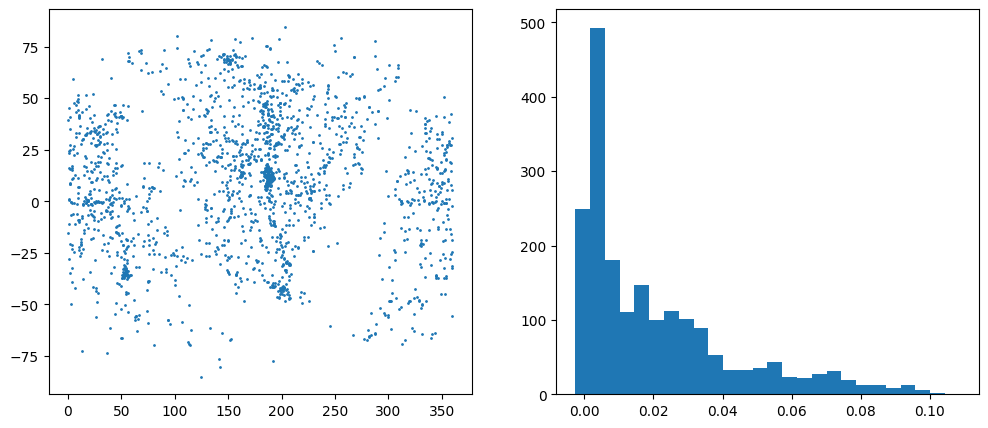

In [3]:
fname_data = "/mnt/extraspace/rstiskalek/catalogs/CF4HQ.txt"
with open(fname_data, "r") as f:
    cols = f.readline().split()

data = np.genfromtxt(fname_data, skip_header=1)

RA = data[:, cols.index("RA") + 1]
DEC = data[:, cols.index("Dec") + 1]
Vcmb = data[:, cols.index("Vcmb") + 1]
zcmb = Vcmb / SPEED_OF_LIGHT


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(RA, DEC, s=1, )
axs[1].hist(zcmb, bins="auto")

fig.show()

In [4]:
flow_path = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

fname_samples = paths.flow_validation(
    flow_path, "Carrick2015", ["CF4_TFR_i", "CF4_TFR_notSDSS_w1"],
    inference_method="bayes", fdir_subfolder="calibration",
    sample_alpha=True, zcmb_max=0.05, remove_CF4_outliers=True)



samples = get_some_samples(fname_samples, ["Vext_cartesian", "alpha", "beta", "sigma_v"])
downsample = 8
for key in samples:
    samples[key] = samples[key][::downsample]

samples["Vext"] *= 0
samples["alpha"] = samples["alpha_CF4_TFR_notSDSS_w1"]

print(f"We are left with {len(samples['sigma_v'])} samples")



loader = csiborgtools.flow.DataLoader(
    "Carrick2015", [0], "CF4_HQ_Federico",
    fname_data, paths, ksmooth=0, )

r = loader.rdist
los_velocity = loader.los_radial_velocity[0]
los_density = loader.los_density[0]

obs2cosmo = csiborgtools.flow.Observed2CosmologicalRedshift(samples, r, 0.3)



File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/calibration/samples_Carrick2015_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_sample_alpha_remove_CF4_outliers.hdf5
Last modified: 23/03/2025 02:07:56
We are left with 1875 samples
2025-03-23 16:47:12,397 reading the catalogue,
2025-03-23 16:47:12,453 reading the interpolated field.


2025-03-23 16:47:12,878 calculating the radial velocity.
2025-03-23 16:47:13,721 the gradient of comoving distance with respect to redshift is undefined for the first step. Setting it to the value of the second step since this point is at the origin.


In [5]:
from tqdm import tqdm


def compute_pdf(i):
    if zcmb[i] > 0.05:
        return i, np.full(obs2cosmo.nsteps, np.nan)

    _, result = obs2cosmo.posterior_zcosmo(
        zcmb[i], RA[i], DEC[i], los_density[i], los_velocity[i], verbose=False)
    return i, result

results = Parallel(n_jobs=32)(
    delayed(compute_pdf)(i) for i in tqdm(range(len(RA)))
)

pdf = np.full((len(RA), obs2cosmo.nsteps), np.nan)
for i, row in results:
    pdf[i] = row

  0%|          | 0/1956 [00:00<?, ?it/s]/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


100%|██████████| 1956/1956 [00:53<00:00, 36.78it/s]


In [6]:
zcosmo_mean = np.full(len(RA), np.nan)
zcosmo_std = np.full(len(RA), np.nan)

for i in trange(len(RA)):
    zcosmo_mean[i], zcosmo_std[i] = obs2cosmo.posterior_mean_std(
        obs2cosmo.zcos_xrange, pdf[i])
    

100%|██████████| 1956/1956 [00:16<00:00, 120.24it/s]


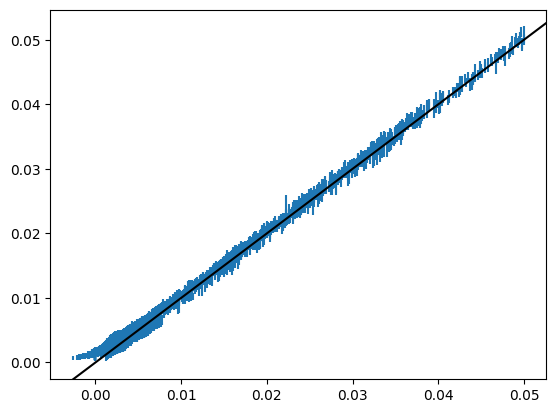

In [8]:
plt.figure()
plt.errorbar(zcmb, zcosmo_mean, yerr=zcosmo_std, fmt="none")
plt.axline([0, 0], slope=1, color="black")

plt.show()

In [22]:
from astropy.cosmology import FlatLambdaCDM

d_inferred = FlatLambdaCDM(75, 0.3).comoving_distance(zcosmo_mean).value
e_d_inferred = FlatLambdaCDM(75, 0.3).comoving_distance(zcosmo_mean + zcosmo_std).value - d_inferred


dTRGB = data[:, cols.index("dTRGB") + 1]
e_dTRGB = data[:, cols.index("edTRGB") + 1]

dCPLR = data[:, cols.index("dCeph") + 1]
e_dCPLR = data[:, cols.index("edCeph") + 1] 

dSBF = data[:, cols.index("dSBF") + 1]
e_dSBF = data[:, cols.index("edSBF") + 1]

dMaser = data[:, cols.index("dMas") + 1]
e_dMaser = data[:, cols.index("edMas") + 1]

dSNIa = data[:, cols.index("dSNIa") + 1]
e_dSNIa = data[:, cols.index("edSNIa") + 1]

dSNII = data[:, cols.index("dSNII") + 1]
e_dSNII = data[:, cols.index("edSNII") + 1]




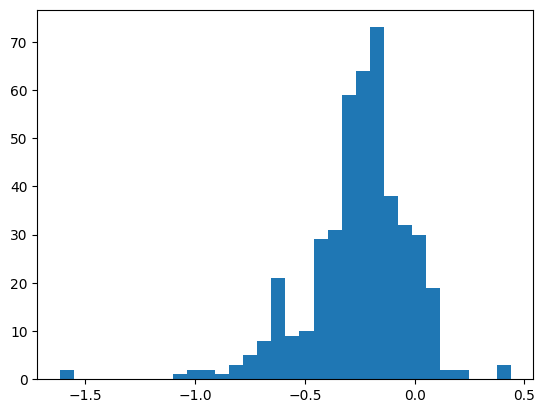

In [10]:
# x = dTRGB - d_inferred
x = np.log10(dTRGB) - np.log10(d_inferred)
x = x[~np.isnan(x)]

plt.figure()
plt.hist(x, bins="auto")
plt.show()

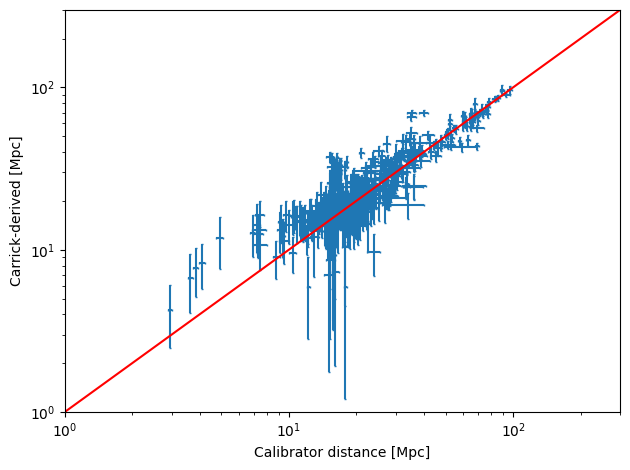

In [23]:
plt.figure()


# plt.errorbar(dTRGB, d_inferred, xerr=e_dTRGB, yerr=e_d_inferred, fmt="none", capsize=1)
# plt.errorbar(dCPLR, d_inferred, xerr=e_dCPLR, yerr=e_d_inferred, fmt="none", capsize=1)
plt.errorbar(dSBF, d_inferred, xerr=e_dSBF, yerr=e_d_inferred, fmt="none", capsize=1)

# plt.errorbar(d_inferred, dCPLR, yerr=e_dCPLR, fmt="none", capsize=3)
# plt.scatter(d_inferred, dSBF, s=2.5)

# plt.errorbar(d_inferred, dMaser, yerr=e_dMaser, fmt="none", capsize=3)
# plt.errorbar(d_inferred, dSNIa, yerr=e_dSNIa, fmt="none", capsize=3)

# plt.errorbar(dTRGB, d_inferred, xerr=e_dTRGB, fmt="none", capsize=3, c="red")


# plt.errorbar(d_inferred, dSNII, yerr=e_dSNII, fmt="none", capsize=3, c="red")


plt.axline([0, 0], slope=1, color="black", c="red")
plt.xlabel("Calibrator distance [Mpc]")
plt.ylabel("Carrick-derived [Mpc]")

plt.xlim(1, 300)
plt.ylim(1, 300)
plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.savefig("calibrator_vs_carrick.png", dpi=300)

# plt.xscale("log")
# plt.yscale("log")

plt.show()